In [1]:
import matplotlib.pyplot as plt
import nivapy3 as nivapy
import pandas as pd
import seaborn as sn
import utils

plt.style.use("ggplot")

# Colours for plots
COLOUR_DICT = {
    "Akvakultur": "royalblue",
    "Jordbruk": "sienna",
    "Avløp": "red",
    "Industri": "darkgrey",
    "Bebygd": "gold",
    "Bakgrunn": "limegreen",
    "Menneskeskapt": "pink",
    "Totalt": "black",
}
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=list(COLOUR_DICT.values()))

# Oslofjord P trends

Extending the overview of nitrogen trends for Oslofjord to inlcude other parameters.

In [2]:
# Define vassdragsområder for Oslofjord
#  - Inner Oslofjord vassoms 005 to 009
#  - Outer Oslofjord vassoms 001 to 004 and 010 to 014
#  - Whole Oslofjord vassoms 001 to 014
vassom_dict = {
    "Indre Oslofjord": list(range(5, 10)),
    "Ytre Oslofjord": list(range(1, 5)) + list(range(10, 18)),
    "Hele Oslofjord": list(range(1, 18)),
}

## 1. TEOTIL3

TEOTIL3 provides simulations of TOTP, TPP and TDP from 2013 to the present.

### 1.1. User input

In [3]:
# Pars of interest
teo3_pars = ["totp", "tdp"]

# Period of interest
st_yr, end_yr = 2013, 2023
nve_data_yr = 2024

# Agricultural dataset to use
agri_loss_model = "annual"

### 1.2. Aggregate model results to Oslofjord regions of interest

In [4]:
df_list = []
for area, vassom_list in vassom_dict.items():
    vassom_ids = [f"{i:03d}." for i in vassom_list]
    area_df = utils.get_teotil3_results(
        st_yr,
        end_yr,
        vassom_ids,
        agri_loss_model,
        nve_data_yr,
    )
    for par in teo3_pars:
        par_df = utils.aggregate_parameters(area_df, par).copy()
        par_df["Menneskeskapt"] = (
            par_df["Akvakultur"]
            + par_df["Jordbruk"]
            + par_df["Avløp"]
            + par_df["Industri"]
            + par_df["Bebygd"]
        )
        par_df["Totalt"] = par_df["Menneskeskapt"] + par_df["Bakgrunn"]
        par_df = par_df.groupby("År").sum(numeric_only=True).reset_index()
        par_df["Område"] = area
        par_df["Parameter"] = par.upper()

        df_list.append(par_df)

df = pd.concat(df_list, axis="rows")
id_cols = ["Område", "Parameter", "År"]
value_cols = [col for col in df.columns if col not in id_cols]
df = df[id_cols + value_cols]
df.head()

,Område,Parameter,År,Akvakultur,Jordbruk,Avløp,Industri,Bebygd,Bakgrunn,Menneskeskapt,Totalt
0,Indre Oslofjord,TOTP,2013,0.0,13.255955,42.520045,0.0,14.062617,3.279312,69.838617,73.117929
1,Indre Oslofjord,TOTP,2014,0.0,16.713200,55.229340,0.0,21.556465,5.007332,93.499004,98.506336
2,Indre Oslofjord,TOTP,2015,0.0,16.422411,58.114547,0.0,20.644178,4.850207,95.181137,100.031344
3,Indre Oslofjord,TOTP,2016,0.0,13.640707,41.341367,0.0,14.555339,3.437102,69.537414,72.974516
4,Indre Oslofjord,TOTP,2017,0.0,13.391001,48.197438,0.0,13.942952,3.228908,75.531391,78.760299


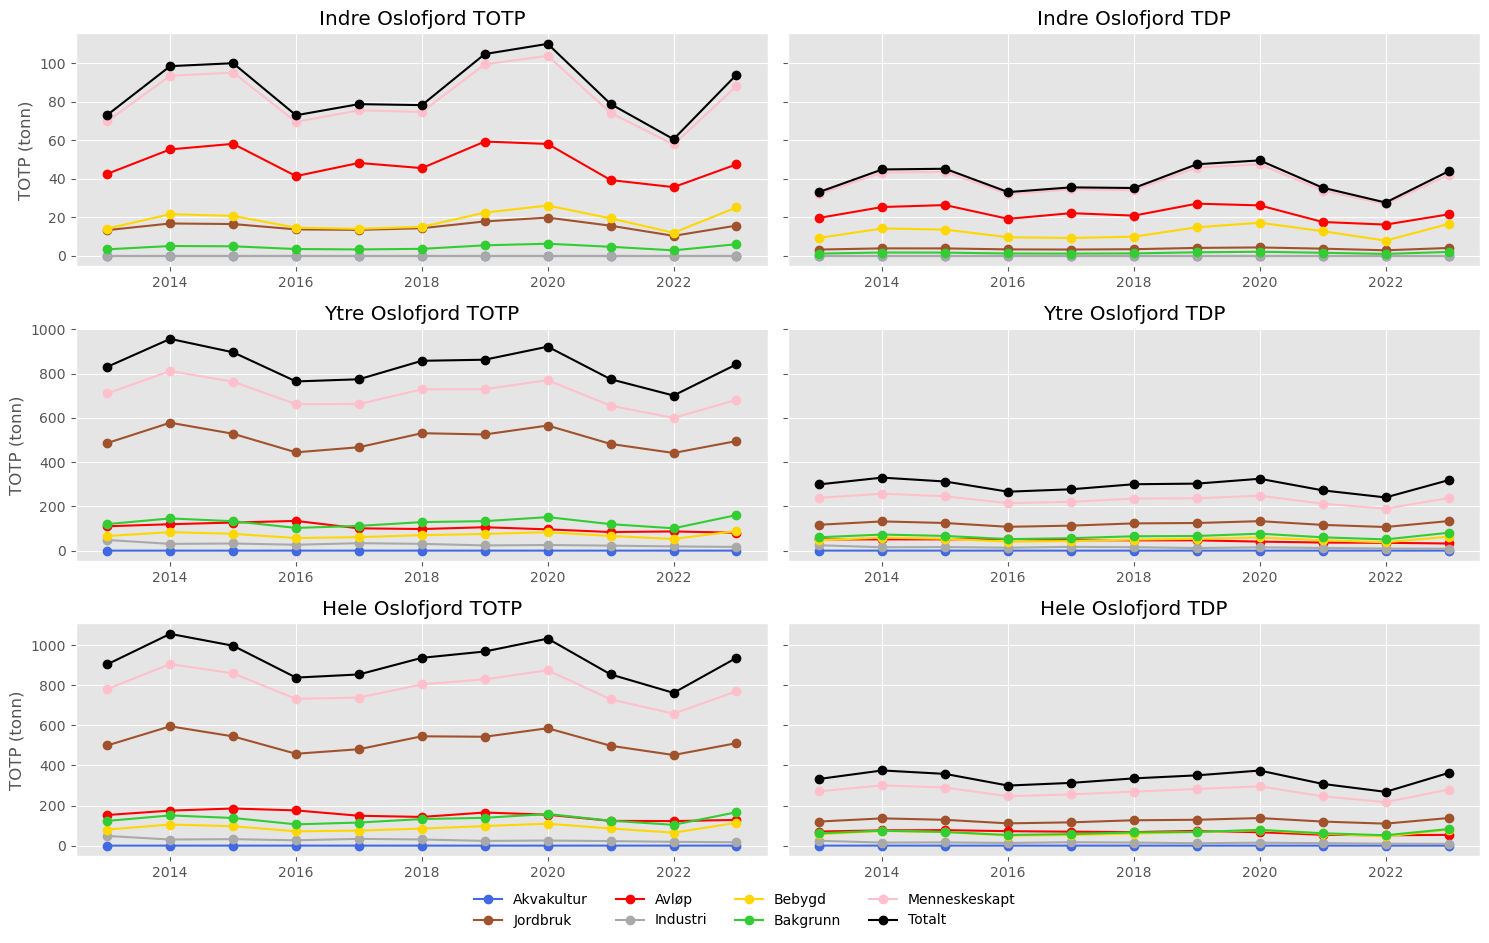

In [5]:
# Plot
nrows = len(vassom_dict.keys())
fig, axes = plt.subplots(nrows=nrows, ncols=2, sharey="row", figsize=(15, nrows * 3))
for row_idx, area in enumerate(vassom_dict.keys()):
    for col_idx, par in enumerate(teo3_pars):
        par = par.upper()
        par_df = df.query("(`Område` == @area) and (Parameter == @par)").copy()
        par_df = par_df.drop(columns=["Område", "Parameter"]).set_index("År")
        par_df.plot(ax=axes[row_idx, col_idx], marker="o", legend=False)
        axes[row_idx, col_idx].set_title(f"{area} {par.upper()}")
        axes[row_idx, col_idx].set_xlabel("")
        axes[row_idx, col_idx].set_ylabel(f"{par.upper()} (tonn)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.05),
)

plt.tight_layout()

plt.savefig("teo3_oslofjord_p_loads_2013-2023.png", dpi=200, bbox_inches="tight")

### 1.3. Test for trends

Results from TEOTIL3 (2013 - 2023):
  Indre Oslofjord totp
    Akvakultur: no trend
    Jordbruk: no trend
    Avløp: no trend
    Industri: no trend
    Bebygd: no trend
    Bakgrunn: no trend
    Menneskeskapt: no trend
    Totalt: no trend
  Indre Oslofjord tdp
    Akvakultur: no trend
    Jordbruk: no trend
    Avløp: no trend
    Industri: no trend
    Bebygd: no trend
    Bakgrunn: no trend
    Menneskeskapt: no trend
    Totalt: no trend
  Ytre Oslofjord totp
    Akvakultur: decreasing
    Jordbruk: no trend
    Avløp: decreasing
    Industri: decreasing
    Bebygd: no trend
    Bakgrunn: no trend
    Menneskeskapt: no trend
    Totalt: no trend
  Ytre Oslofjord tdp
    Akvakultur: decreasing
    Jordbruk: no trend
    Avløp: decreasing
    Industri: decreasing
    Bebygd: no trend
    Bakgrunn: no trend
    Menneskeskapt: no trend
    Totalt: no trend
  Hele Oslofjord totp
    Akvakultur: decreasing
    Jordbruk: no trend
    Avløp: decreasing
    Industri: decreasing
    Bebyg

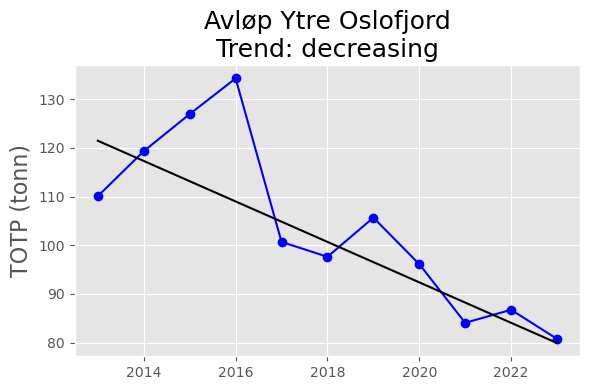

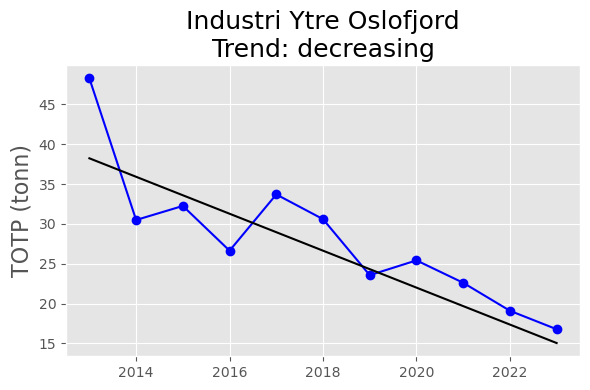

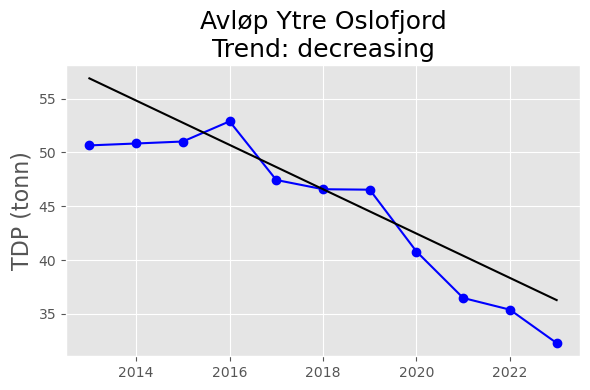

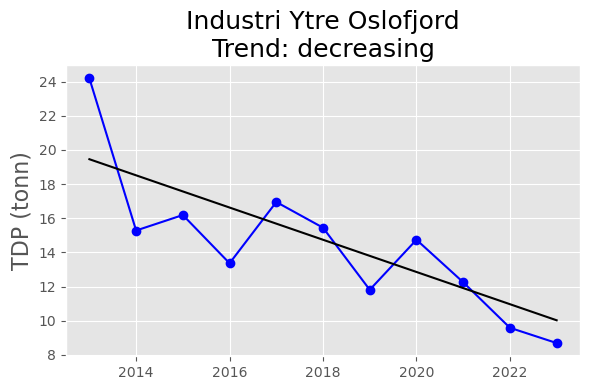

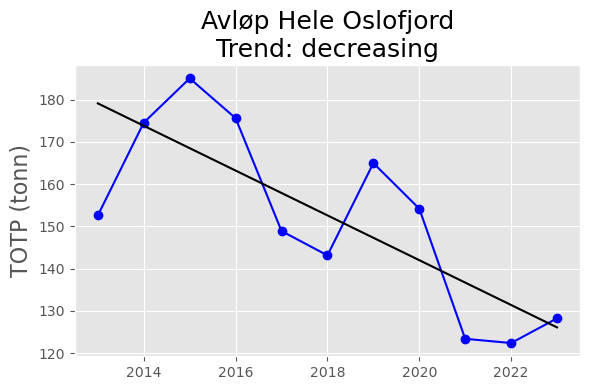

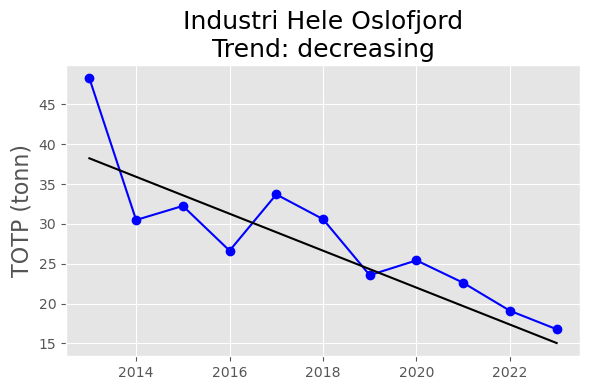

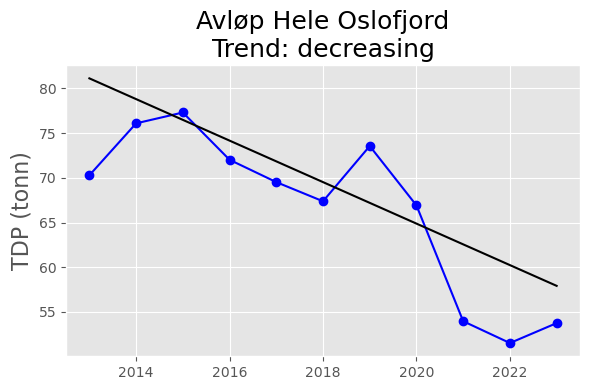

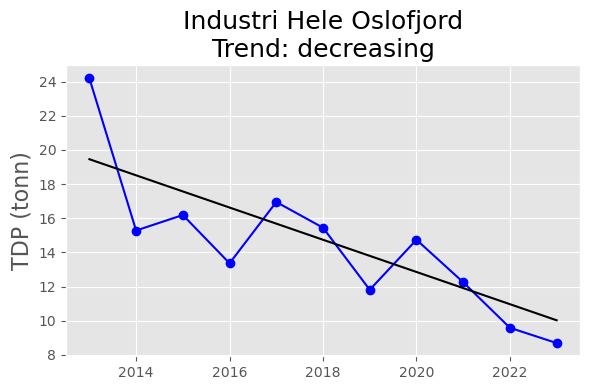

In [6]:
# Test for trends in 'Totalt'
print("Results from TEOTIL3 (2013 - 2023):")
for area in vassom_dict.keys():
    for par in teo3_pars:
        print(f"  {area} {par}")
        for src in value_cols:
            par = par.upper()
            par_df = df.query("(`Område` == @area) and (Parameter == @par)").copy()
            mk_df = nivapy.stats.mk_test(par_df, src, alpha=0.05)
            trend = mk_df.loc["trend", "value"]
            if trend in ("increasing", "decreasing") and (src != "Akvakultur"):
                res_df, sen_df = nivapy.stats.sens_slope(
                    par_df, src, index_col="År", alpha=0.05
                )
                nivapy.plotting.plot_sens_slope(
                    res_df,
                    sen_df,
                    ylabel=f"{par} (tonn)",
                    title=f"{src} {area}\nTrend: {trend}",
                )

            print(f"    {src}: {trend}")

## 2. Elveovervåkingsprogrammet

### 2.1. Define monitoring stations around Oslofjord

5 of the Oslofjord's main rivers are monitored as part of Elveovervåkingsprogrammet. The total land area of the Oslofjord catchment is around 85 000 km2. The code below first estimates what proportion of this is covered by the monitoring.

In [7]:
stn_dict = {
    29612: ["Drammenselva", "012.A3"],
    36225: ["Alna", "006.2A0"],
    29613: ["Skienselva", "016.A222"],
    29615: ["Numedalslågen", "015.A1"],
    29617: ["Glomma", "002.A51"],
}
obs_pars = ["totp", "po4-p"]
osl_cat_area = 85000  # km2

In [8]:
area_df = pd.read_csv(
    f"/home/jovyan/shared/common/teotil3/evaluation/teo3_results_nve{nve_data_yr}_{st_yr}-{end_yr}_agri-{agri_loss_model}-loss.csv"
)
mon_area = 0
for stn_id, (name, reg_id) in stn_dict.items():
    stn_area_df = area_df.query("(regine == @reg_id)")[
        ["regine", "accum_upstr_area_km2"]
    ]
    mon_area += stn_area_df.iloc[0, 1]

prop_mon = 100 * mon_area / osl_cat_area
print(f"Area monitored: {mon_area:.1f} km2.")
print(
    f"Proportion of Oslofjord catchment covered by monitoring under Elveovervåkingsprogrammet: {prop_mon:.1f} %."
)

Area monitored: 74985.9 km2.
Proportion of Oslofjord catchment covered by monitoring under Elveovervåkingsprogrammet: 88.2 %.


Nearly 90 % of the Oslofjord catchment area is covered by Elveovervåkingsprogrammet. This means we should be able to get a good overview of dominant trends directly from the monitoring data.

### 2.2. Read observed fluxes calculated by Elveovervåkingsprogrammet

In [9]:
# Read observed
obs_path = r"/home/jovyan/shared/common/elveovervakingsprogrammet/results/measured_loads/loads_and_flows_rid_20_1990-2023.csv"
obs_df = pd.read_csv(obs_path)

### 2.3. Compare monitored data to TEOTIL3 results for 2013 to 2023

This is to test TEOTIL3. If the model does a reasonable job of reproducing observed fluxes, we can have more confidence in the simulations for Oslofjord overall (see section 1).

In [10]:
# Calculate 'observed DIN' from NO3 and NH4
obs_df["TDP_tonnes"] = obs_df["PO4-P_tonnes"]

# Get dataset comparing modelled versus observed fluxes
df_list = []
for stn_id, (name, reg_id) in stn_dict.items():
    # Get modelled data
    stn_df_teo3 = utils.get_teotil3_results(
        st_yr, end_yr, [reg_id], agri_loss_model, nve_data_yr
    )
    for par in teo3_pars:
        # Get observed data
        stn_par_df_obs = obs_df.query(
            "(station_id == @stn_id) and (year >= @st_yr) and (year <= @end_yr)"
        )[["station_id", "year", f"{par.upper()}_tonnes"]].copy()
        stn_par_df_obs.columns = ["station_id", "year", "load_tonnes"]
        stn_par_df_obs["par"] = par.upper()
        stn_par_df_obs["name"] = name
        stn_par_df_obs["type"] = "Observed"

        # Get modelled data for par
        stn_par_df_teo3 = utils.aggregate_parameters(stn_df_teo3, par).copy()
        stn_par_df_teo3["Menneskeskapt"] = (
            stn_par_df_teo3["Akvakultur"]
            + stn_par_df_teo3["Jordbruk"]
            + stn_par_df_teo3["Avløp"]
            + stn_par_df_teo3["Industri"]
            + stn_par_df_teo3["Bebygd"]
        )
        stn_par_df_teo3["Totalt"] = (
            stn_par_df_teo3["Menneskeskapt"] + stn_par_df_teo3["Bakgrunn"]
        )
        stn_par_df_teo3 = stn_par_df_teo3[["År", "Totalt"]]
        stn_par_df_teo3.columns = ["year", "load_tonnes"]
        stn_par_df_teo3["par"] = par.upper()
        stn_par_df_teo3["station_id"] = stn_id
        stn_par_df_teo3["name"] = name
        stn_par_df_teo3["type"] = "TEOTIL3"

        df_list.append(stn_par_df_obs)
        df_list.append(stn_par_df_teo3)

comp_df = pd.concat(df_list, axis="rows")[
    ["station_id", "name", "par", "year", "type", "load_tonnes"]
]
comp_df.head()

,station_id,name,par,year,type,load_tonnes
57,29612,Drammenselva,TOTP,2013,Observed,110.922952
58,29612,Drammenselva,TOTP,2014,Observed,72.148616
59,29612,Drammenselva,TOTP,2015,Observed,140.256422
60,29612,Drammenselva,TOTP,2016,Observed,91.888625
61,29612,Drammenselva,TOTP,2017,Observed,67.884941


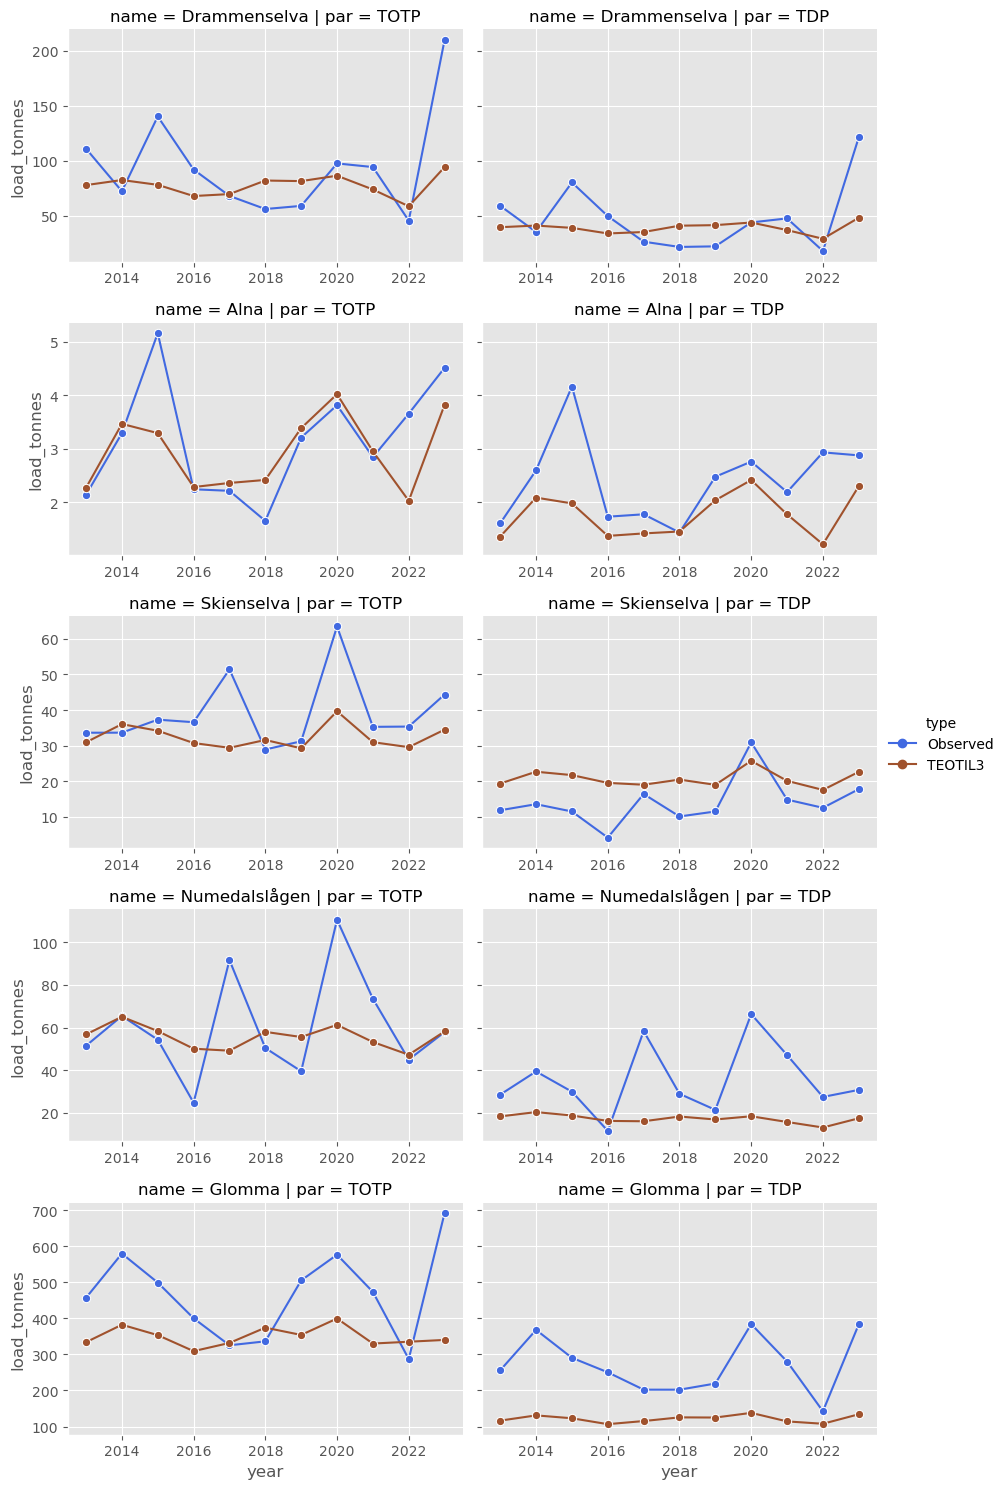

In [11]:
# Plot
sn.relplot(
    data=comp_df,
    x="year",
    y="load_tonnes",
    hue="type",
    row="name",
    col="par",
    kind="line",
    marker="o",
    height=3,
    aspect=1.5,
    facet_kws={"sharey": "row", "sharex": False},
)

plt.savefig("teo3_vs_monitored_p_2013-2023.png", dpi=200, bbox_inches="tight")

In [12]:
# Test for trends
print("Comparing TEOTIL3 and observed trends for 2013 to 2023:")
for stn_id, (name, reg_id) in stn_dict.items():
    for par in teo3_pars:
        print(f"  {par.upper()} at {name}:")
        for res_type in ["Observed", "TEOTIL3"]:
            par = par.upper()
            res_df = comp_df.query(
                "(station_id == @stn_id) and (par == @par) and (type == @res_type)"
            ).copy()
            mk_df = nivapy.stats.mk_test(res_df, "load_tonnes", alpha=0.05)
            trend = mk_df.loc["trend", "value"]
            print(f"    {res_type} trend: {trend}")

Comparing TEOTIL3 and observed trends for 2013 to 2023:
  TOTP at Drammenselva:
    Observed trend: no trend
    TEOTIL3 trend: no trend
  TDP at Drammenselva:
    Observed trend: no trend
    TEOTIL3 trend: no trend
  TOTP at Alna:
    Observed trend: no trend
    TEOTIL3 trend: no trend
  TDP at Alna:
    Observed trend: no trend
    TEOTIL3 trend: no trend
  TOTP at Skienselva:
    Observed trend: no trend
    TEOTIL3 trend: no trend
  TDP at Skienselva:
    Observed trend: no trend
    TEOTIL3 trend: no trend
  TOTP at Numedalslågen:
    Observed trend: no trend
    TEOTIL3 trend: no trend
  TDP at Numedalslågen:
    Observed trend: no trend
    TEOTIL3 trend: no trend
  TOTP at Glomma:
    Observed trend: no trend
    TEOTIL3 trend: no trend
  TDP at Glomma:
    Observed trend: no trend
    TEOTIL3 trend: no trend


The plots in section 2.3 show that TEOTIL3 does a reasonable job of simulating observed river flows as measured by Elveovervåkingsprogrammet. Statistical analyses of both modelled and observed data series confirm that there are no significant trends in either TOTP or TDP over the past decade. This supports the results from section 1 (which consider regions of the Oslofjord, rather than specific rivers).

**Based on this, there is no evidence of significant changes in phosphorus inputs (TOTP or TDP) to any region of the Oslofjord within the past decade**.

## 3. Longer monitoring series

Some of the rivers in Elveovervåkingsprogrammet have data going back to the 1990s. This allows us to consider longer trends, as well as separating NO3 and NH4.

In [13]:
df_list = []
for stn_id, (name, reg_id) in stn_dict.items():
    for par in obs_pars:
        # Get observed data
        stn_par_df_obs = obs_df.query("(station_id == @stn_id)")[
            ["station_id", "year", f"{par.upper()}_tonnes"]
        ].copy()
        stn_par_df_obs.columns = ["station_id", "year", "load_tonnes"]
        stn_par_df_obs["par"] = par.upper()
        stn_par_df_obs["name"] = name
        df_list.append(stn_par_df_obs)

elv_df = pd.concat(df_list, axis="rows")[
    ["station_id", "name", "par", "year", "load_tonnes"]
]
elv_df.head()

,station_id,name,par,year,load_tonnes
34,29612,Drammenselva,TOTP,1990,56.204185
35,29612,Drammenselva,TOTP,1991,38.000236
36,29612,Drammenselva,TOTP,1992,46.277875
37,29612,Drammenselva,TOTP,1993,52.699311
38,29612,Drammenselva,TOTP,1994,58.529301


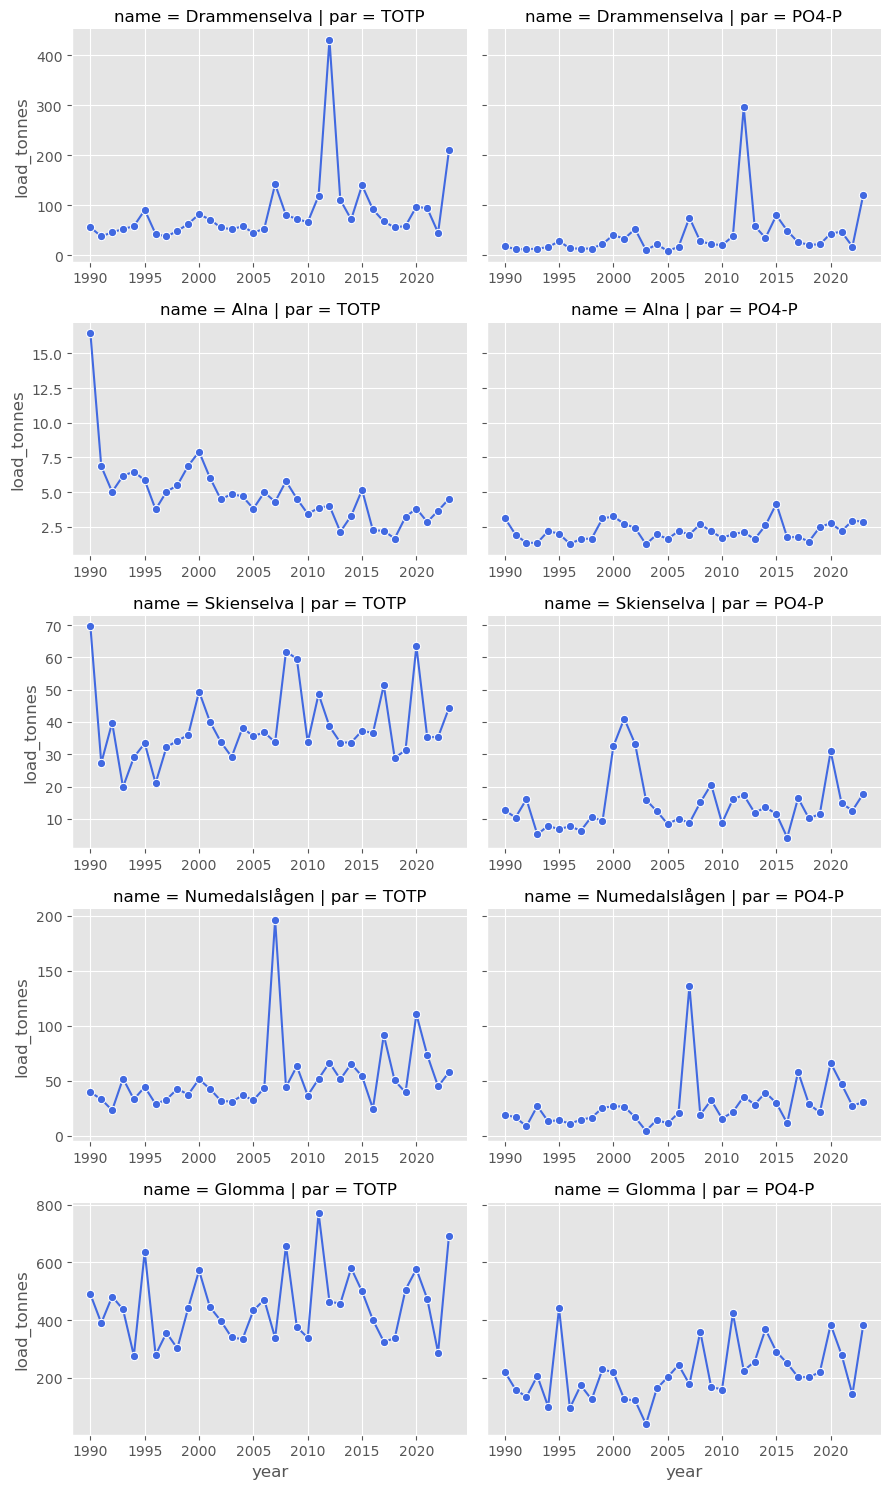

In [14]:
# Plot
sn.relplot(
    data=elv_df,
    x="year",
    y="load_tonnes",
    row="name",
    col="par",
    col_order=[i.upper() for i in obs_pars],
    kind="line",
    marker="o",
    height=3,
    aspect=1.5,
    facet_kws={"sharey": "row", "sharex": False},
)
plt.savefig("monitored_p_loads_rid_rivers_1990-2023.png", dpi=200, bbox_inches="tight")

In [15]:
# Test for trends
print("Observed trends for 1990 to 2023:")
for stn_id, (name, reg_id) in stn_dict.items():
    print(name)
    for par in obs_pars:
        par = par.upper()
        res_df = elv_df.query("(station_id == @stn_id) and (par == @par)").copy()
        mk_df = nivapy.stats.mk_test(res_df, "load_tonnes", alpha=0.05)
        sen_res_df, sen_df = nivapy.stats.sens_slope(
            res_df, "load_tonnes", index_col="year", alpha=0.05
        )
        trend = mk_df.loc["trend", "value"]
        sslp = sen_res_df.loc['sslp', 'value']
        print(f"  {par.upper()}: {trend} ({sslp:.1f} tonnes/year)")

Observed trends for 1990 to 2023:
Drammenselva
  TOTP: increasing (1.4 tonnes/year)
  PO4-P: increasing (0.8 tonnes/year)
Alna
  TOTP: decreasing (-0.1 tonnes/year)
  PO4-P: no trend (0.0 tonnes/year)
Skienselva
  TOTP: no trend (0.2 tonnes/year)
  PO4-P: no trend (0.2 tonnes/year)
Numedalslågen
  TOTP: increasing (0.8 tonnes/year)
  PO4-P: increasing (0.7 tonnes/year)
Glomma
  TOTP: no trend (1.7 tonnes/year)
  PO4-P: increasing (4.0 tonnes/year)


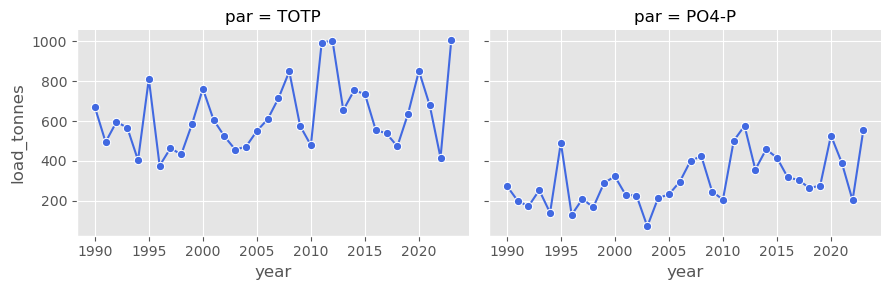

In [16]:
# Combine monitoring data for Oslofjord
osl_df = (
    elv_df.groupby(["par", "year"])
    .sum(numeric_only=True)[["load_tonnes"]]
    .reset_index()
)

# Plot
sn.relplot(
    data=osl_df,
    x="year",
    y="load_tonnes",
    col="par",
    col_order=[i.upper() for i in obs_pars],
    kind="line",
    marker="o",
    height=3,
    aspect=1.5,
    facet_kws={"sharey": "row", "sharex": False},
)
plt.savefig("monitored_p_loads_oslofjord_1990-2023.png", dpi=200, bbox_inches="tight")


 TOTP


,description,value
sslp,Median slope estimate,5.620173
icpt,Estimated intercept,-10686.254988
lb,Lower bound on slope estimate at specified alpha,-0.732271
ub,Upper bound on slope estimate at specified alpha,11.421688
trend,Type of trend (if present),no trend



 PO4-P


,description,value
sslp,Median slope estimate,6.35114
icpt,Estimated intercept,-12467.685625
lb,Lower bound on slope estimate at specified alpha,2.308468
ub,Upper bound on slope estimate at specified alpha,10.602144
trend,Type of trend (if present),increasing


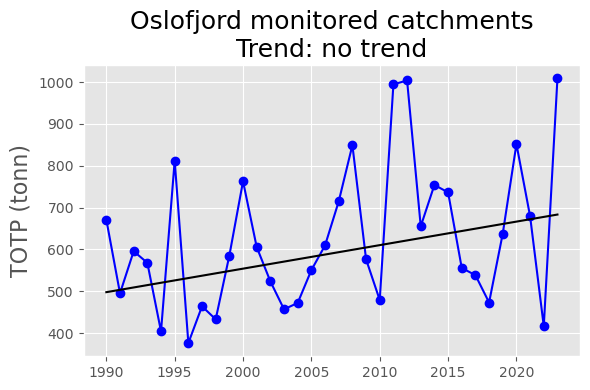

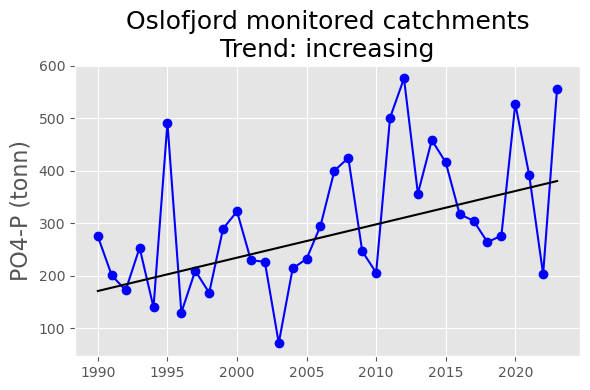

In [17]:
# Test for trends
for par in obs_pars:
    par = par.upper()
    par_df = osl_df.query("par == @par").copy()
    mk_df = nivapy.stats.mk_test(par_df, "load_tonnes", alpha=0.05)
    res_df, sen_df = nivapy.stats.sens_slope(
        par_df, "load_tonnes", index_col="year", alpha=0.05
    )
    trend = mk_df.loc["trend", "value"]
    print("\n", par)
    display(res_df)
    nivapy.plotting.plot_sens_slope(
        res_df,
        sen_df,
        ylabel=f"{par} (tonn)",
        title=f"Oslofjord monitored catchments\nTrend: {trend}",
    )
    plt.savefig(
        f"monitored_loads_trend_{par.lower()}_1990-2023.png",
        dpi=200,
        bbox_inches="tight",
    )